In [1]:
#Objective: To analyze Patient's Data and identify key factors associated with stroke occurence

In [53]:
#imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [3]:
#file import
filename = "healthcare-dataset-stroke-data.csv"
df = pd.read_csv(filename)

In [4]:
#understanding Data structure
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.shape

(5110, 12)

In [6]:
#data cleaning
#missing values and duplicates
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
#filling missing bmi with median
df['bmi'] =df['bmi'].fillna(df['bmi'].median())

In [9]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [10]:
#checking data types
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [11]:
#convert binary columns to readable levels
binary_cols =['stroke','hypertension','heart_disease']
for col in binary_cols:
    df[col]=df[col].map({0: 'No',1:'Yes'})

In [12]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,51676,Female,61.0,No,No,Yes,Self-employed,Rural,202.21,28.1,never smoked,Yes
2,31112,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
3,60182,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
4,1665,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes


In [13]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension          object
heart_disease         object
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                object
dtype: object

In [14]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(col, df[col].unique())

gender ['Male' 'Female' 'Other']
hypertension ['No' 'Yes']
heart_disease ['Yes' 'No']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type ['Urban' 'Rural']
smoking_status ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
stroke ['Yes' 'No']


In [15]:
numeric_cols = df.select_dtypes(include =['float64','int64']).columns
df[numeric_cols].describe()

,id,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,106.147677,28.862035
std,21161.721625,22.612647,45.283560,7.699562
min,67.000000,0.080000,55.120000,10.300000
25%,17741.250000,25.000000,77.245000,23.800000
50%,36932.000000,45.000000,91.885000,28.100000
75%,54682.000000,61.000000,114.090000,32.800000
max,72940.000000,82.000000,271.740000,97.600000


In [16]:
df[df['age']<1]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
363,7559,Female,0.64,No,No,No,children,Urban,83.82,24.9,Unknown,No
376,22706,Female,0.88,No,No,No,children,Rural,88.11,15.5,Unknown,No
564,61511,Female,0.32,No,No,No,children,Rural,73.71,16.2,Unknown,No
982,54747,Male,0.88,No,No,No,children,Rural,157.57,19.2,Unknown,No
996,53279,Male,0.24,No,No,No,children,Rural,118.87,16.3,Unknown,No
1093,66772,Female,0.32,No,No,No,children,Rural,55.86,16.0,Unknown,No
1206,68908,Female,0.72,No,No,No,children,Urban,66.36,23.0,Unknown,No
1317,30084,Male,0.80,No,No,No,children,Rural,98.67,17.5,Unknown,No
1600,40544,Male,0.40,No,No,No,children,Urban,109.56,14.3,Unknown,No
1614,47350,Female,0.08,No,No,No,children,Urban,139.67,14.1,Unknown,No


In [22]:
df[df['age']<1].shape[0]

43

In [17]:
df[df['work_type']=='children']

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
162,69768,Female,1.32,No,No,No,children,Urban,70.37,28.1,Unknown,Yes
245,49669,Female,14.00,No,No,No,children,Rural,57.93,30.9,Unknown,Yes
249,30669,Male,3.00,No,No,No,children,Rural,95.12,18.0,Unknown,No
282,33759,Female,3.00,No,No,No,children,Urban,73.74,16.0,Unknown,No
290,55680,Male,13.00,No,No,No,children,Urban,114.84,18.3,Unknown,No
...,...,...,...,...,...,...,...,...,...,...,...,...
5089,56714,Female,0.72,No,No,No,children,Rural,62.13,16.8,Unknown,No
5094,28048,Male,13.00,No,No,No,children,Urban,82.38,24.3,Unknown,No
5095,68598,Male,1.08,No,No,No,children,Rural,79.15,17.4,Unknown,No
5098,579,Male,9.00,No,No,No,children,Urban,71.88,17.5,Unknown,No


In [18]:
#drop rows with ages less than 1 year
df= df[df['age'] >=1]

df['age'].min()

1.0

In [30]:
#choosing target variables

In [19]:
#count of stroke vs no stroke
stroke_counts = df['stroke'].value_counts()
print(stroke_counts)

#percentage
stroke_percent = df['stroke'].value_counts(normalize=True)*100
print(stroke_percent)

stroke
No     4818
Yes     249
Name: count, dtype: int64
stroke
No     95.08585
Yes     4.91415
Name: proportion, dtype: float64


In [30]:
categories = categorical_cols.tolist()
categories.remove('stroke')

In [31]:
print(categories)

['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [32]:
#function to summarize categorical features
def summarize_categorical(df,cat_cols,target='stroke'):
    summary = {}
    for col in cat_cols:
        counts = pd.crosstab(df[col],df[target])
        percentages = counts.div(counts.sum(axis=1),axis=0)*100
        summary[col] = {'counts':counts,'percentages':percentages}
    return summary

In [33]:
cat_summary = summarize_categorical(df,categories,target='stroke')

In [34]:
for col, stats in cat_summary.items():
    print(f"\n=== {col.upper()} ===")
    print("Counts: \n", stats['counts'])
    print("Percentages:\n", stats['percentages'])


=== GENDER ===
Counts: 
 stroke    No  Yes
gender           
Female  2838  141
Male    1979  108
Other      1    0
Percentages:
 stroke          No       Yes
gender                      
Female   95.266868  4.733132
Male     94.825108  5.174892
Other   100.000000  0.000000

=== HYPERTENSION ===
Counts: 
 stroke          No  Yes
hypertension           
No            4386  183
Yes            432   66
Percentages:
 stroke               No        Yes
hypertension                      
No            95.994747   4.005253
Yes           86.746988  13.253012

=== HEART_DISEASE ===
Counts: 
 stroke           No  Yes
heart_disease           
No             4589  202
Yes             229   47
Percentages:
 stroke                No        Yes
heart_disease                      
No             95.783761   4.216239
Yes            82.971014  17.028986

=== EVER_MARRIED ===
Counts: 
 stroke          No  Yes
ever_married           
No            1685   29
Yes           3133  220
Percentages:
 stroke    

In [35]:
target_category =('ever_married','smoking_status','work_type','heart_disease','hypertension')

In [37]:
numeric_cols = numeric_cols.drop(['id'])

In [38]:
def summarize_numeric(df,numeric_cols,target='stroke'):
    summary_dict = {}
    for col in numeric_cols:
        stats = df.groupby(target)[col].describe().round(2)
        summary_dict[col] = stats
    return summary_dict
    

In [39]:
num_summary_dict = summarize_numeric(df, numeric_cols, target='stroke')

In [40]:
for col, stats in num_summary_dict.items():
    print(f"\n=== {col.upper()} ===")
    display(stats)


=== AGE ===


,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
No,4818.0,42.34,22.04,1.00,25.0,44.0,59.0,82.0
Yes,249.0,67.73,12.73,1.32,59.0,71.0,78.0,82.0



=== AVG_GLUCOSE_LEVEL ===


,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
No,4818.0,104.88,43.96,55.12,77.17,91.53,112.90,267.76
Yes,249.0,132.54,61.92,56.11,79.79,105.22,196.71,271.74



=== BMI ===


,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
No,4818.0,28.89,7.74,10.3,23.7,28.1,32.8,97.6
Yes,249.0,30.09,5.86,16.9,27.0,28.1,32.5,56.6


In [41]:
target_numeric =('age','avg_glucose_level','bmi')

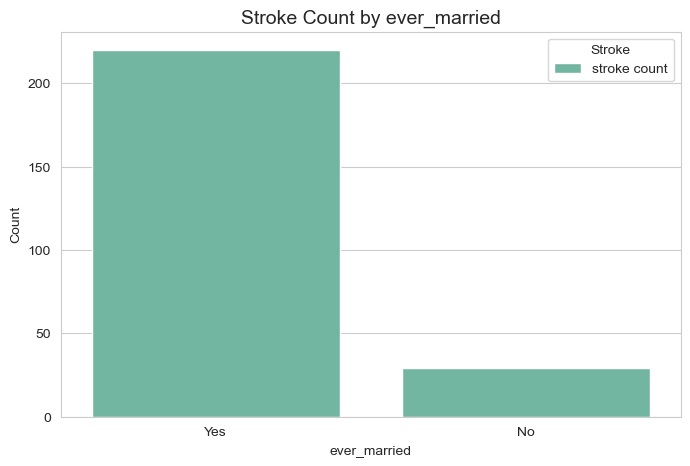

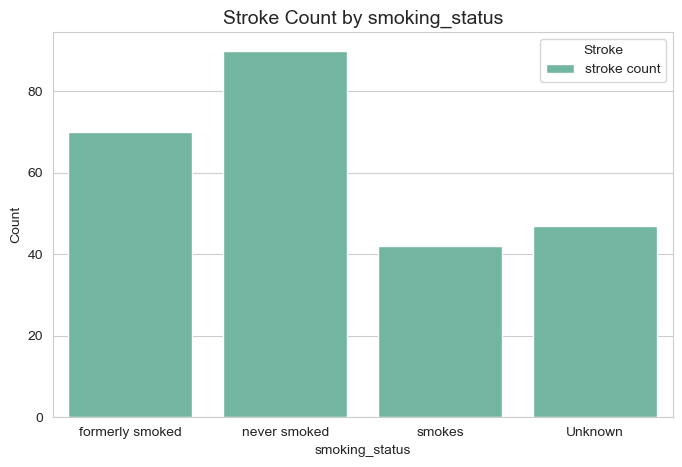

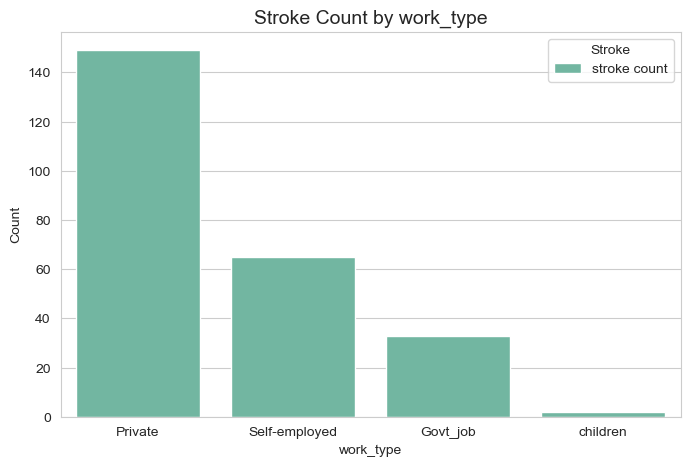

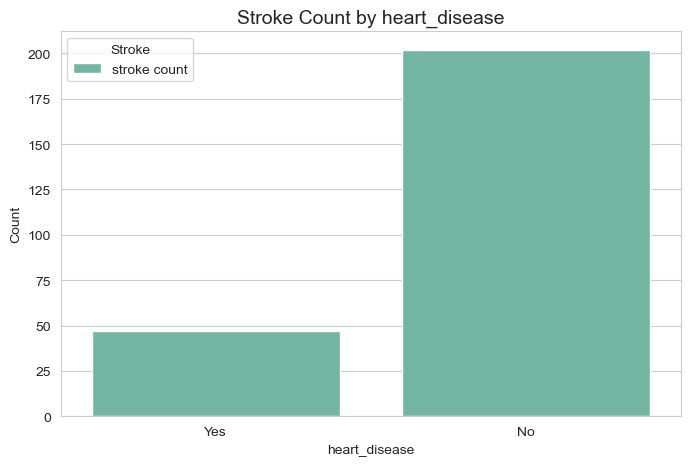

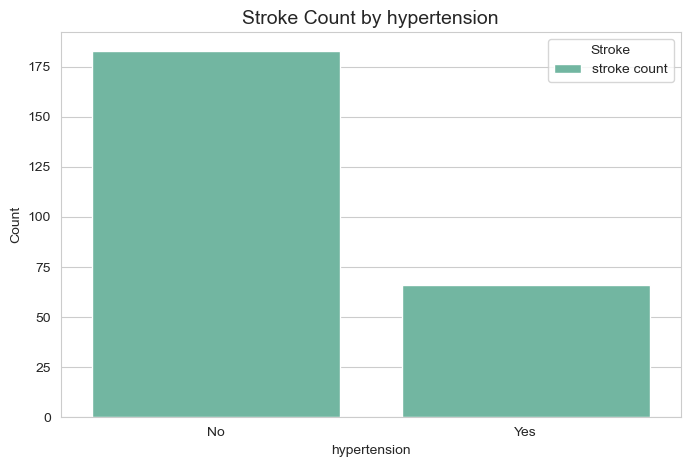

In [44]:
#categorical features visualization
stroke_df =df[df['stroke']=='Yes']
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(8,5)


for col in target_category:
    plt.figure()
    sns.countplot(data=stroke_df, x=col, hue='stroke', palette='Set2')
    plt.title(f'Stroke Count by {col}',fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Stroke', labels=['stroke count'])
    plt.show()

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_7736\3163230872.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df,palette='Set3')


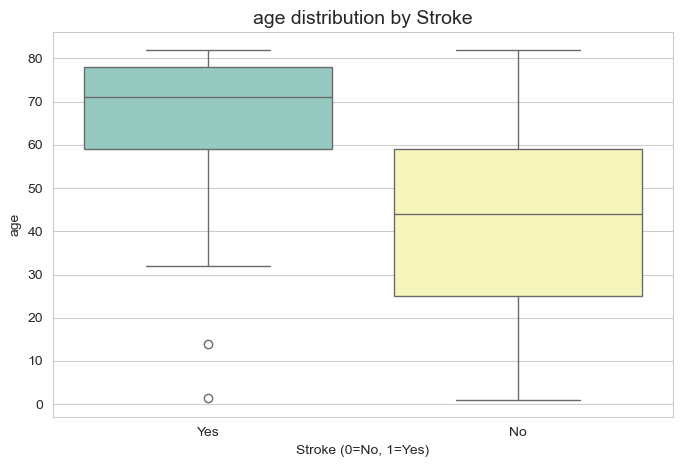

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_7736\3163230872.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df,palette='Set3')


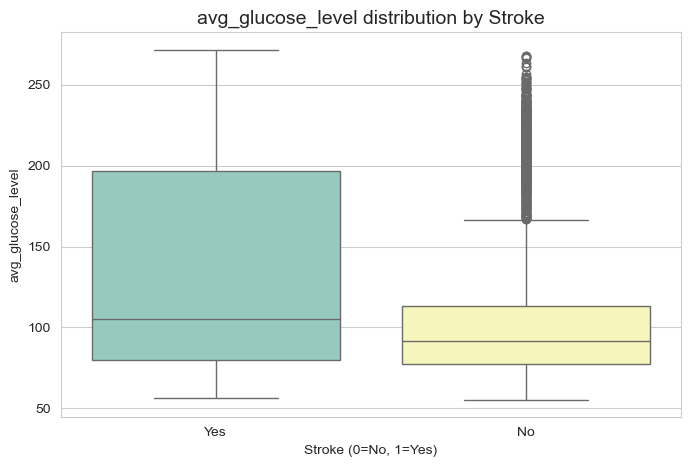

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_7736\3163230872.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df,palette='Set3')


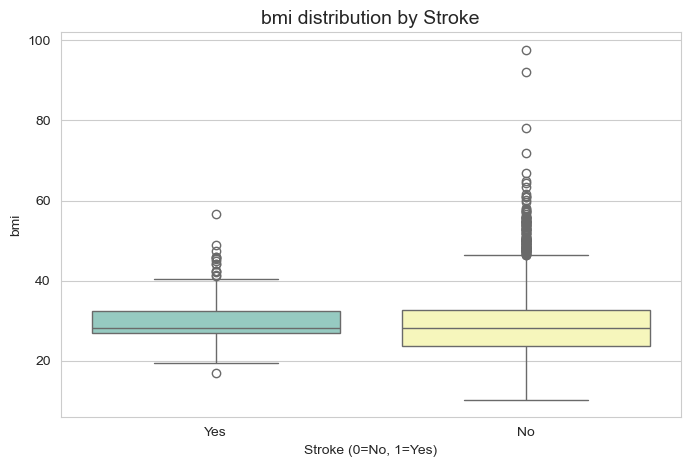

In [45]:
#numeric visualization
for col in target_numeric:
    plt.figure()
    sns.boxplot(x='stroke', y=col, data=df,palette='Set3')
    plt.title(f'{col} distribution by Stroke', fontsize=14)
    plt.xlabel('Stroke (0=No, 1=Yes)')
    plt.ylabel(col)
    plt.show()

In [52]:
#numeric correlation
target_numeric_list = list(target_numeric)
df['stroke_numeric'] = df['stroke'].map({'No':0, 'Yes':1})

corr= df[target_numeric_list + ['stroke_numeric']].corr()

print(corr['stroke_numeric'].sort_values(ascending=False))

stroke_numeric       1.000000
age                  0.245426
avg_glucose_level    0.131739
bmi                  0.033811
Name: stroke_numeric, dtype: float64


In [54]:
#chisquare test for categorical
for col in target_category:
    contingency_table=pd.crosstab(df[col],df['stroke'])
    chi2,p,dof,expected= chi2_contingency(contingency_table)
    print(f'{col} -> p-value: {p}')

ever_married -> p-value: 5.5748592921627114e-14
smoking_status -> p-value: 4.431799431083927e-06
work_type -> p-value: 1.8689454429191926e-09
heart_disease -> p-value: 4.019114357067039e-21
hypertension -> p-value: 3.348288122740266e-19


In [68]:
export_cols = list(target_category + target_numeric + ('stroke',))
print(export_cols)

['ever_married', 'smoking_status', 'work_type', 'heart_disease', 'hypertension', 'age', 'avg_glucose_level', 'bmi', 'stroke']


In [69]:
df_export=df[export_cols]

In [70]:
df_export.to_csv('stroke_analysis_dataset.csv',index=False)